In [1]:
import os
os.chdir('..')

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pickle
from ipywidgets import interact, FloatSlider

from agent.eval.realtime_chunking import RealtimeActionChunkingBuffer

In [3]:
chunking = pickle.load(open('debug/bedug-rca.pkl', 'rb'))
env_t0, robs = pickle.load(open('debug/bedrug-robs.pkl', 'rb'))
acts = pickle.load(open('debug/bedug-acts.pkl', 'rb'))

chunks = [d['chunk'] for d in chunking]
obs = [d['obs'] for d in chunking]
t_proc = np.array([d['t'] for d in chunking])

t_act = np.array([a[0] for a in acts])
eval_acts = np.array([a[1][0] for a in acts])

t0 = t_proc[0]
buf = RealtimeActionChunkingBuffer(1/5, weight_decay=.5)

In [4]:
actions = []
ix = 0
buf._chunks = []
act_ts = t_act - t0
for t in act_ts:
    if t + t0 >= t_proc[ix]:
        buf._chunks.append(chunks[ix])
        ix += 1
    action = buf.get_action(t + t0)
    if action is None:
        print('??', t)
        continue
    act, _ = action
    actions.append(act)
actions = np.array(actions)

?? 5.212974548339844
?? 5.411099672317505
?? 5.612992763519287
?? 5.819445610046387
?? 6.015721797943115
?? 6.213780879974365
?? 6.414046049118042
?? 6.613562822341919
?? 6.812668800354004
?? 7.01348352432251
?? 7.215480804443359
?? 7.413283109664917
?? 7.616572856903076
?? 7.814049959182739
?? 8.014606237411499
?? 8.224622964859009
?? 8.41828465461731
?? 8.618883609771729
?? 8.820979118347168
?? 9.019014835357666
?? 9.219856262207031
?? 9.431774377822876
?? 9.625181674957275
?? 9.824477672576904
?? 10.022094249725342
?? 10.225242853164673
?? 10.42487382888794
?? 10.622489213943481
?? 10.822055101394653
?? 11.023344993591309
?? 11.23107099533081
?? 11.431427478790283
?? 11.623281478881836
?? 11.82832384109497
?? 12.024685382843018
?? 12.223087549209595
?? 12.423081159591675
?? 12.6252121925354
?? 12.831914186477661
?? 13.026047468185425
?? 13.22811770439148
?? 13.430209159851074
?? 13.62866473197937
?? 13.829559326171875
?? 14.031749486923218
?? 14.230124473571777
?? 14.431760787963867

interactive(children=(FloatSlider(value=-0.5, description='t', max=3.5, min=-1.0, step=0.01), Output()), _dom_…

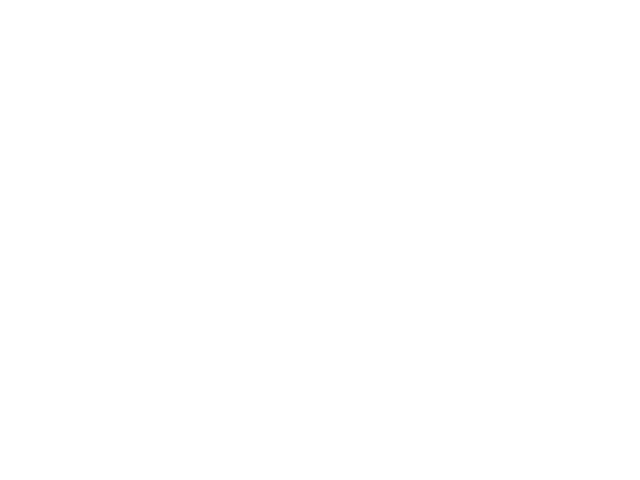

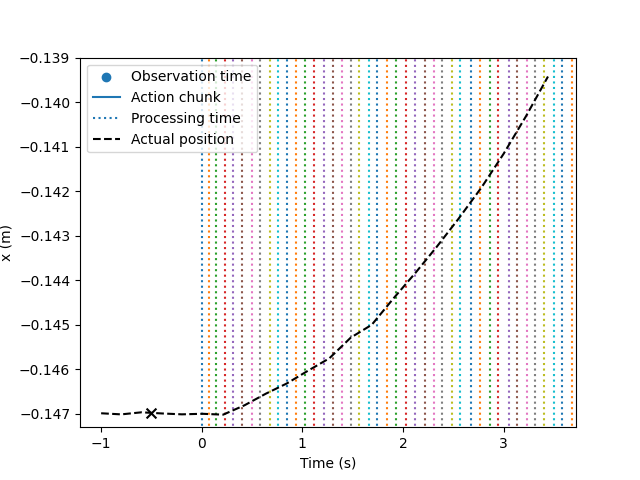

In [5]:
ix = 0
a, b = -1, 3.5

tcur = 3.5

actual = np.array([(env_t0 + ri.time - t0, ri.actual_pose[ix]) for ri in robs])
actual = actual[(a <= actual[:,0]) & (actual[:, 0] < b)]

act_sel = (a <= act_ts) & (act_ts < b)

fig, ax = plt.subplots()

scatters = []
plots = []
vlines = []
for i in range(0, 50):
    sc = ax.scatter(chunks[i].times[0] - t0, chunks[i].poses[0, ix])
    pl, = ax.plot(chunks[i].times - t0, chunks[i].poses[:, ix])
    vl = ax.vlines(t_proc[i] - t0, -1, 1, f'C{i}', linestyle='dotted')
    scatters.append(sc)
    plots.append(pl)
    vlines.append(vl)

dot = ax.scatter(actual[0, 0], actual[0, 1], marker='x', c='k', s=50, zorder=5)

pos, = ax.plot(*actual[::100].T, 'k--')
# cmd, = ax.plot(act_ts[act_sel], actions[act_sel, ix], 'k.-')

# ax.legend([scatters[0], plots[0], vlines[0], pos, cmd], ['Observation time', 'Action chunk', 'Processing time', 'Actual position', 'Command position'])
ax.legend([scatters[0], plots[0], vlines[0], pos], ['Observation time', 'Action chunk', 'Processing time', 'Actual position', 'Command position'])

ax.set_xlabel('Time (s)')
ax.set_ylabel('x (m)')

ax.set_xlim(-1.21, 3.72)
ax.set_ylim(-.1473, -.139)


@interact(t=FloatSlider(min=a, max=b, value=-.5, step=0.01))
def f(t):
    tix = np.argmin(np.abs(actual[:, 0] - t))
    dot.set_offsets([actual[tix]])
    for i in range(len(scatters)):
        if t_proc[i] - t0 < t:
            scatters[i].set_visible(True)
            plots[i].set_visible(True)
        else:
            scatters[i].set_visible(False)
            plots[i].set_visible(False)
    fig.canvas.draw_idle()
